In [1]:
# imports
import os
import tensorflow as tf
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, UpSampling2D, Add
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from pycocotools.coco import COCO

In [2]:
# Constantes
NUM_CLASSES = 5
IMAGE_WIDTH = 768
IMAGE_HEIGHT = 576
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS = 3
COCO_PATH = 'data/piloto_coco_labels'
COCO_PATH_train = 'data/piloto_coco_labels/train.json'
COCO_PATH_val = 'data/piloto_coco_labels/val.json'
LABEL_PATH = 'data/piloto_labelme_labels'
IMG_PATH = 'data/piloto_H4_data_1_images'
clases = ['Taza', 'Onepiece', 'Tanque', 'Lavamanos', 'Pedestal']
LEARNING_RATE = 1e-3
EPOCHS = 10
BATCH_SIZE = 2
SHUFFLE = 100
LOSS_FUNCTION = 'categorical_crossentropy'
METRICS = ["accuracy"]
SEMILLA = 1

In [3]:
import labelme2coco

# set directory that contains labelme annotations and image files
labelme_folder = LABEL_PATH

# set export dir
export_dir = COCO_PATH

# set train split rate
train_split_rate = 0.85

# convert labelme annotations to coco
labelme2coco.convert(labelme_folder, export_dir, train_split_rate)

There are 153 listed files in folder data/piloto_labelme_labels.


Converting labelme annotations to COCO format: 100%|██████████| 153/153 [00:00<00:00, 219.51it/s]
03/27/2025 07:30:08 - INFO - labelme2coco -   Training split in COCO format is exported to data\piloto_coco_labels\train.json
03/27/2025 07:30:08 - INFO - labelme2coco -   Validation split in COCO format is exported to data\piloto_coco_labels\val.json


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


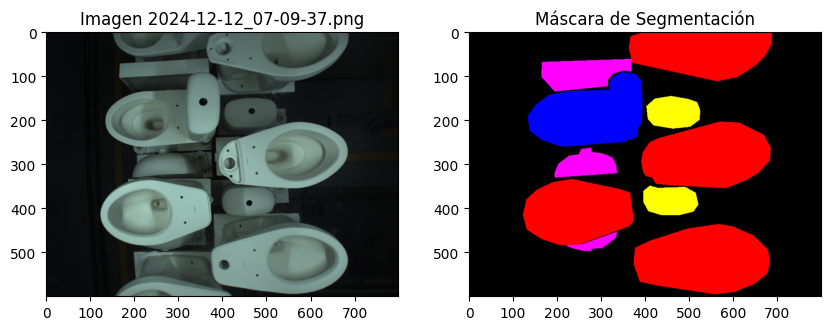

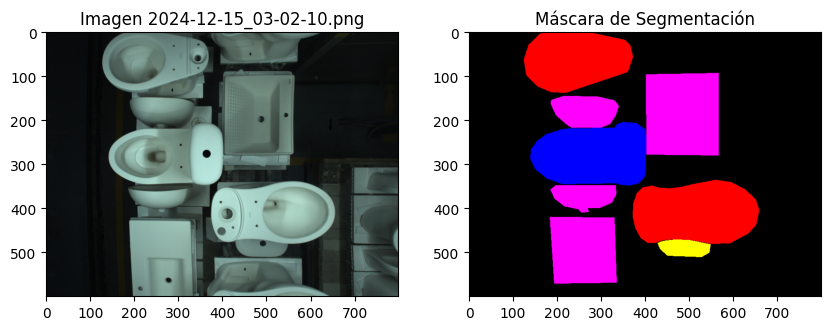

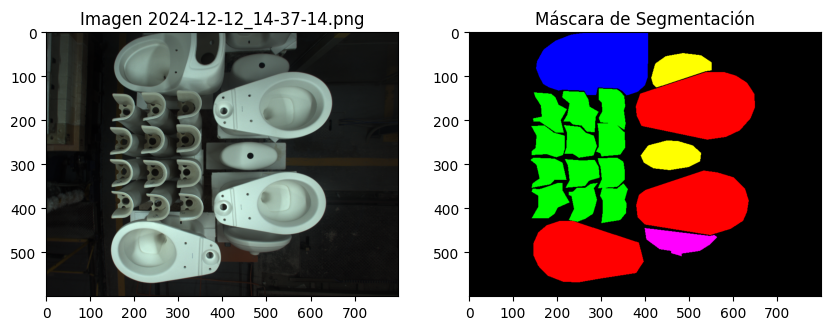

In [77]:
#  Función para explorar el dataset y mostrar imágenes + máscaras
def visualizar_dataset(coco_annotation_file, num_images=3):
    coco = COCO(coco_annotation_file)
    image_ids = list(coco.imgs.keys())

    category_colors = {
        0: (255, 0, 0),   # Rojo
        1: (0, 255, 0),   # Verde
        2: (0, 0, 255),   # Azul
        3: (255, 255, 0), # Amarillo
        4: (255, 0, 255), # Magenta
    }

    for i in range(num_images):
        image_id = image_ids[i]
        image_info = coco.imgs[image_id]
        image_path = os.path.join('data', image_info['file_name'].split('..')[1][1:])
        image = cv.imread(image_path)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        
        # Cargar anotaciones y generar la máscara
        mask = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        annotations = coco.loadAnns(coco.getAnnIds(imgIds=image_id))
        for ann in annotations:
            segmentation = coco.annToMask(ann)
            color = category_colors.get(ann['category_id'], (255, 255, 255))
            mask[segmentation > 0] = color
            # fig1, ax1 = plt.subplots(1, 1, figsize=(10, 5))
            # ax1.imshow(segmentation)
            # ax1.set_title("Imagen")
        
        # Mostrar imagen y máscara en color
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(image)
        ax[0].set_title("Imagen " + image_path[29:])
        ax[1].imshow(mask)
        ax[1].set_title("Máscara de Segmentación")
        plt.show()

visualizar_dataset(COCO_PATH_train)

In [5]:
#  Aumento de Datos
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEMILLA),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [6]:
# Prueba rutas

# coco = COCO(COCO_PATH_dataset)
# image_ids = list(coco.imgs.keys())
# for i, image_id in enumerate(image_ids):
#     image_info = coco.imgs[image_id]
#     image_path = os.path.join('data', image_info['file_name'].split('..')[1][1:])
#     image = cv.imread(image_path)
#     salida = os.path.join('data', 'caca', str(i)+'.png')
#     cv.imwrite(salida, image)

In [7]:
def load_coco_dataset(coco_annotation_file, input_size, augment=False):
    coco = COCO(coco_annotation_file)
    image_ids = list(coco.imgs.keys())

    def generator():
        for image_id in image_ids:
            image_info = coco.imgs[image_id]
            image_path = os.path.join('data', image_info['file_name'].split('..')[1][1:])
            image = cv.imread(image_path)
            image = cv.resize(image, (input_size[1], input_size[0]))
            image = image / 255.0  # Normalizar

            # Cargar la máscara
            annotations = coco.loadAnns(coco.getAnnIds(imgIds=image_id))
            mask = np.zeros(input_size, dtype=np.uint8)
            for ann in annotations:
                segmentation = coco.annToMask(ann)
                segmentation = cv.resize(segmentation, (input_size[1], input_size[0]))
                mask = np.maximum(mask, segmentation * ann['category_id'])

            image = tf.convert_to_tensor(image, dtype=tf.float32)
            mask = tf.keras.utils.to_categorical(mask, num_classes=len(coco.cats))

            if augment:
                image = data_augmentation(image)

            yield image, mask

    return tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(*input_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(*input_size, len(coco.cats)), dtype=tf.float32),
        ),
    )

#  Cargar el dataset con aumento de datos en entrenamiento
train_dataset = load_coco_dataset(COCO_PATH_train, IMAGE_SIZE, augment=True).batch(BATCH_SIZE).shuffle(SHUFFLE)
val_dataset = load_coco_dataset(COCO_PATH_val, IMAGE_SIZE).batch(BATCH_SIZE)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [9]:
def create_mask_rcnn(input_shape, num_classes):
    # Input
    inputs = tf.keras.Input(shape=input_shape)

    # Backbone: ResNet50
    backbone = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)
    backbone.trainable = True

    # Feature Pyramid Network (FPN)
    c3_output = backbone.get_layer("conv3_block4_out").output
    c4_output = backbone.get_layer("conv4_block6_out").output
    c5_output = backbone.get_layer("conv5_block3_out").output

    # FPN layers
    # primer parametro de conv2D representa el número de filtros o mapas de características 
    # que genera cada operación convolucional.
    p5 = Conv2D(256, (1, 1), padding="same")(c5_output)
    p4 = Add()([UpSampling2D()(p5), Conv2D(256, (1, 1), padding="same")(c4_output)])
    p3 = Add()([UpSampling2D()(p4), Conv2D(256, (1, 1), padding="same")(c3_output)])

    # Head for mask prediction
    mask_head = UpSampling2D(size=(2, 2))(p3)
    mask_head = Conv2D(128, (3, 3), activation="relu", padding="same")(mask_head)
    mask_head = UpSampling2D(size=(2, 2))(mask_head)
    mask_head = Conv2D(64, (3, 3), activation="relu", padding="same")(mask_head)
    mask_head = UpSampling2D(size=(2, 2))(mask_head)  # Upsample to (768, 576)
    mask_output = Conv2D(num_classes, (1, 1), activation="softmax")(mask_head)

    return Model(inputs, mask_output)

# Crear el modelo
model = create_mask_rcnn(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS), num_classes=NUM_CLASSES)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 768, 576, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 774, 582, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 384, 288, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 384, 288, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [10]:
# Verificacion dimensiones

print(train_dataset)
print('Output shape:', model.output_shape)

<_ShuffleDataset element_spec=(TensorSpec(shape=(None, 768, 576, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 768, 576, 5), dtype=tf.float32, name=None))>
Output shape: (None, 768, 576, 5)


In [11]:
# Compilar el modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=LOSS_FUNCTION,
    metrics=METRICS
)

# Entrenar
historial = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)


Epoch 1/10
65/65 [==============================] - 299s 4s/step - loss: 0.8326 - accuracy: 0.7975 - val_loss: 16.2879 - val_accuracy: 0.8065
Epoch 2/10
65/65 [==============================] - 277s 4s/step - loss: 0.6273 - accuracy: 0.8136 - val_loss: 0.6351 - val_accuracy: 0.8065
Epoch 3/10
65/65 [==============================] - 277s 4s/step - loss: 0.6168 - accuracy: 0.8136 - val_loss: 0.6628 - val_accuracy: 0.8065
Epoch 4/10
65/65 [==============================] - 277s 4s/step - loss: 0.6013 - accuracy: 0.8136 - val_loss: 0.7292 - val_accuracy: 0.8065
Epoch 5/10
65/65 [==============================] - 277s 4s/step - loss: 0.5953 - accuracy: 0.8136 - val_loss: 0.7055 - val_accuracy: 0.8065
Epoch 6/10
65/65 [==============================] - 277s 4s/step - loss: 0.5970 - accuracy: 0.8136 - val_loss: 0.7808 - val_accuracy: 0.8065
Epoch 7/10
65/65 [==============================] - 278s 4s/step - loss: 0.5966 - accuracy: 0.8136 - val_loss: 0.6536 - val_accuracy: 0.8065
Epoch 8/10
6

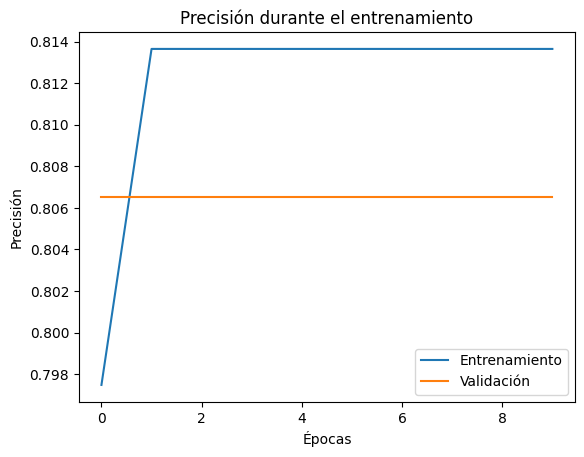

In [ ]:
#  Analizar resultados del entrenamiento
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

1/1 [==============================] - 0s 480ms/step


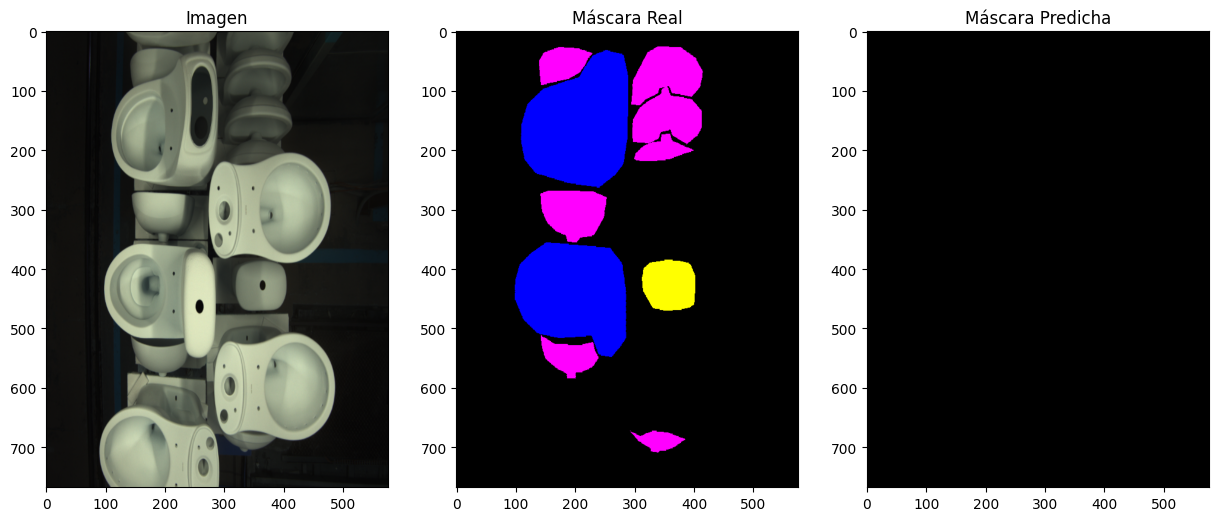

1/1 [==============================] - 1s 501ms/step


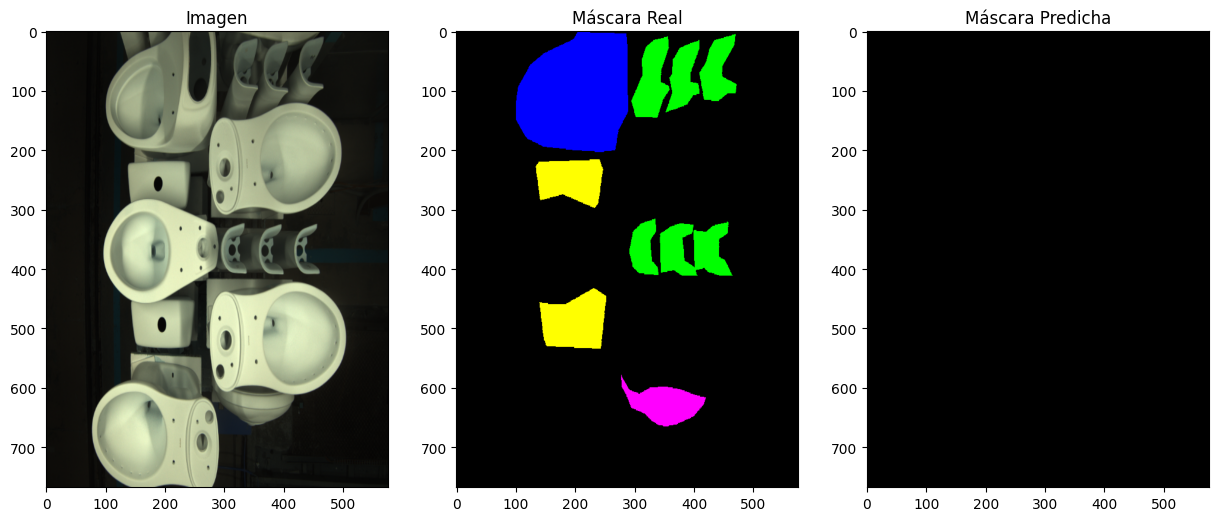

1/1 [==============================] - 0s 490ms/step


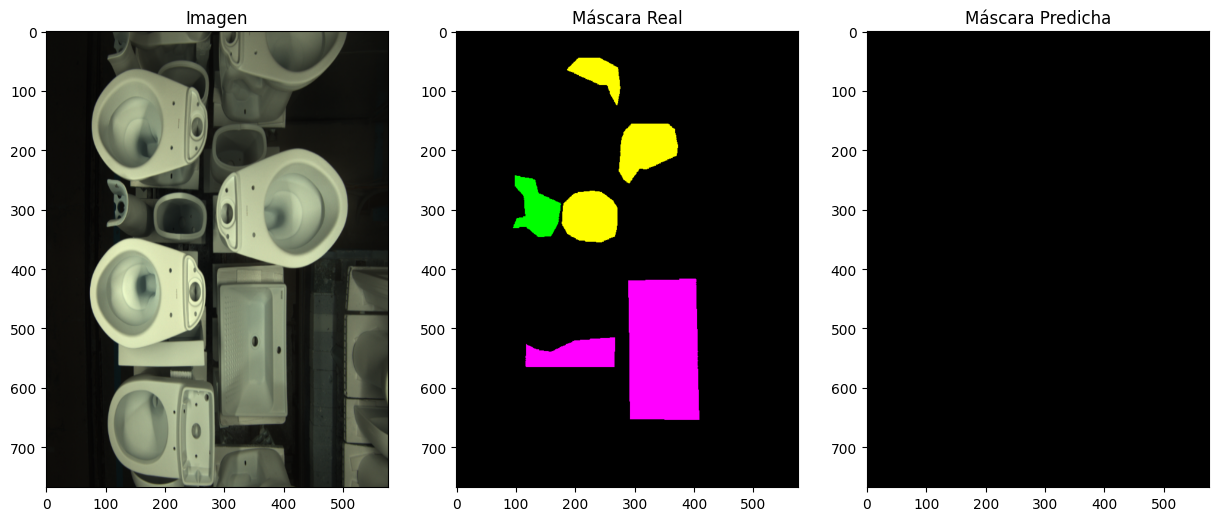

In [ ]:
# Inferencia con el dataset de validación
category_colors = {
    0: (255, 0, 0),   # Rojo
    1: (0, 255, 0),   # Verde
    2: (0, 0, 255),   # Azul
    3: (255, 255, 0), # Amarillo
    4: (255, 0, 255), # Magenta
}

def aplicar_colores(mask, category_colors):
    h, w = mask.shape
    mask_color = np.zeros((h, w, 3), dtype=np.uint8)

    for category_id, color in category_colors.items():
        if category_id != 0:
            mask_color[mask == category_id] = color

    return mask_color

def inferencia(dataset):
    for image, mask_true in dataset.take(3):  
        # Obtener predicción
        pred_mask = model.predict(tf.expand_dims(image[0], axis=0))[0]
        pred_mask = np.argmax(pred_mask, axis=-1)

        # Mascara
        mask_true_np = np.argmax(mask_true[0], axis=-1)
        
        # Colores
        mask_true_colored = aplicar_colores(mask_true_np, category_colors)
        pred_mask_colored = aplicar_colores(pred_mask, category_colors)

        # Mostrar resultados
        fig, ax = plt.subplots(1, 3, figsize=(15, 10))
        ax[0].imshow(image[0])
        ax[0].set_title("Imagen")
        ax[1].imshow(mask_true_colored)
        ax[1].set_title("Máscara Real")
        ax[2].imshow(pred_mask_colored)
        ax[2].set_title("Máscara Predicha")
        plt.show()

inferencia(val_dataset)

In [14]:
# Guardar el modelo
# model.save("instance_segmentation_model_V1.h5")
# model.save("instance_segmentation_model_V1_keras.keras")